In [1]:
import sys
print(sys.executable)

import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

/m/home/home6/69/taivait1/unix/dippa/ceremegbellum/venv/bin/python
2.10.0+cu128
CUDA available: True


In [2]:
import os.path as op
from pathlib import Path
import mne
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mne.datasets import sample
from cmb import get_cerebellum_data, setup_full_source_space, plot_cerebellum_data, CMB_DATA_DIR

In [3]:
data_path = sample.data_path()

# Paths to subject data
sample_dir = op.join(data_path, 'MEG', 'sample',)
raw_fname = op.join(sample_dir, 'sample_audvis_raw.fif')
subjects_dir = op.join(data_path, 'subjects')
subject = 'sample'
trans = op.join(sample_dir, 'sample_audvis_raw-trans.fif')
fname_cov = sample_dir + '/sample_audvis-cov.fif'
evo_fname = sample_dir + '/sample_audvis-ave.fif'

# Check if the required data are available and download if not
get_cerebellum_data()

The required atlas data and segmentation models seem to be downloaded.


In [4]:
# Cerebellar specific
cb_data = pickle.load(open(op.join(CMB_DATA_DIR, 'data', 'cerebellum_geo'), 'rb'))
spacing = 2 # Use spacing 2 to get an approximately equal grid density in cerebral and cerebellar cortices

In [5]:
# Setup source space
cerebellum_subsampling = 'dense'

save_path = Path.cwd()
source_space_save_file = save_path / "full_src.fif"

if source_space_save_file.exists():
    print("Reading source space from file to avoid recomputation")
    src_whole = mne.read_source_spaces(source_space_save_file)
else:
    src_whole = setup_full_source_space(subject, subjects_dir, cerb_subsampling=cerebellum_subsampling,
                                    plot_cerebellum=False, spacing=spacing)
    print(f"Saving source space to {source_space_save_file}")
    src_whole.save(source_space_save_path)

Reading source space from file to avoid recomputation
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read


In [6]:
bem_file = save_path / "bem_solution-sol.fif"
fwd_file = save_path / "forward_solution-fwd.fif"
inv_file = save_path / "inverse_operator-meg-eeg-inv.fif"

In [7]:
# Compute forward and inverse operators
conductivity=(0.3, 0.006, 0.3)
mindist = 3.0 # important not to use too large mindist because the cerebellar cortex and inner skull boundary are usually within 5 mm
model = mne.make_bem_model(subject=subject, ico=4, conductivity=conductivity, subjects_dir=subjects_dir)

if bem_file.exists():
    bem =  mne.read_bem_solution(bem_file)
else:
    bem = mne.make_bem_solution(model) # IF too many source space points are lost, the inner skull boundary is too tight and need to be expanded.
    mne.write_bem_solution(bem_file, bem)

info = mne.io.read_info(raw_fname)

if fwd_file.exists():
    fwd = mne.read_forward_solution(fwd_file)
else:
    fwd = mne.make_forward_solution(info, trans, src_whole, bem=bem, mindist=mindist, eeg=True, n_jobs=1)
    mne.write_forward_solution(fwd_file, fwd)

fwd = mne.convert_forward_solution(fwd, surf_ori=True, force_fixed=True, copy=True)

noise_cov = mne.read_cov(fname_cov)

if inv_file.exists():
    inverse_operator = mne.minimum_norm.read_inverse_operator(inv_file)
else:
    inverse_operator = mne.minimum_norm.make_inverse_operator(info, fwd, noise_cov, depth=None, fixed=True)
    mne.minimum_norm.write_inverse_operator(inv_fname, inverse_operator)

Creating the BEM geometry...
Going from 4th to 4th subdivision of an icosahedron (n_tri: 5120 -> 5120)
Going from 4th to 4th subdivision of an icosahedron (n_tri: 5120 -> 5120)
Going from 4th to 4th subdivision of an icosahedron (n_tri: 5120 -> 5120)
outer skin  CM is  -0.12  -0.14  22.79 mm
outer skull CM is   0.70  -9.88  44.01 mm
inner skull CM is   0.67 -10.01  44.26 mm
Checking that surface outer skull is inside surface outer skin  ...
Checking that surface inner skull is inside surface outer skull ...
Checking distance between outer skin  and outer skull surfaces...
Minimum distance between the outer skin  and outer skull surfaces is approximately    3.7 mm
Checking distance between outer skull and inner skull surfaces...
Minimum distance between the outer skull and inner skull surfaces is approximately    3.5 mm
Surfaces passed the basic topology checks.
Complete.

Loading surfaces...

Loading the solution matrix...

Three-layer model surfaces loaded.
Loaded linear collocation B

Smoothing...
use_tris is None, so we have to spread estimates over entire cortical source space...


/m/home/home6/69/taivait1/unix/dippa/ceremegbellum/cmb/visualization.py:102: RuntimeWarning: Mean of empty slice
  estimate_smoothed[nan_verts] = [np.nanmean(estimate_smoothed[vert_neighbor_group]) for vert_neighbor_group in vert_neighbors]


Widget(value='<iframe src="http://localhost:43787/index.html?ui=P_0x7c5be8814f80_0&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:43787/index.html?ui=P_0x7c5ae72ff680_1&reconnect=auto" class="pyvi…

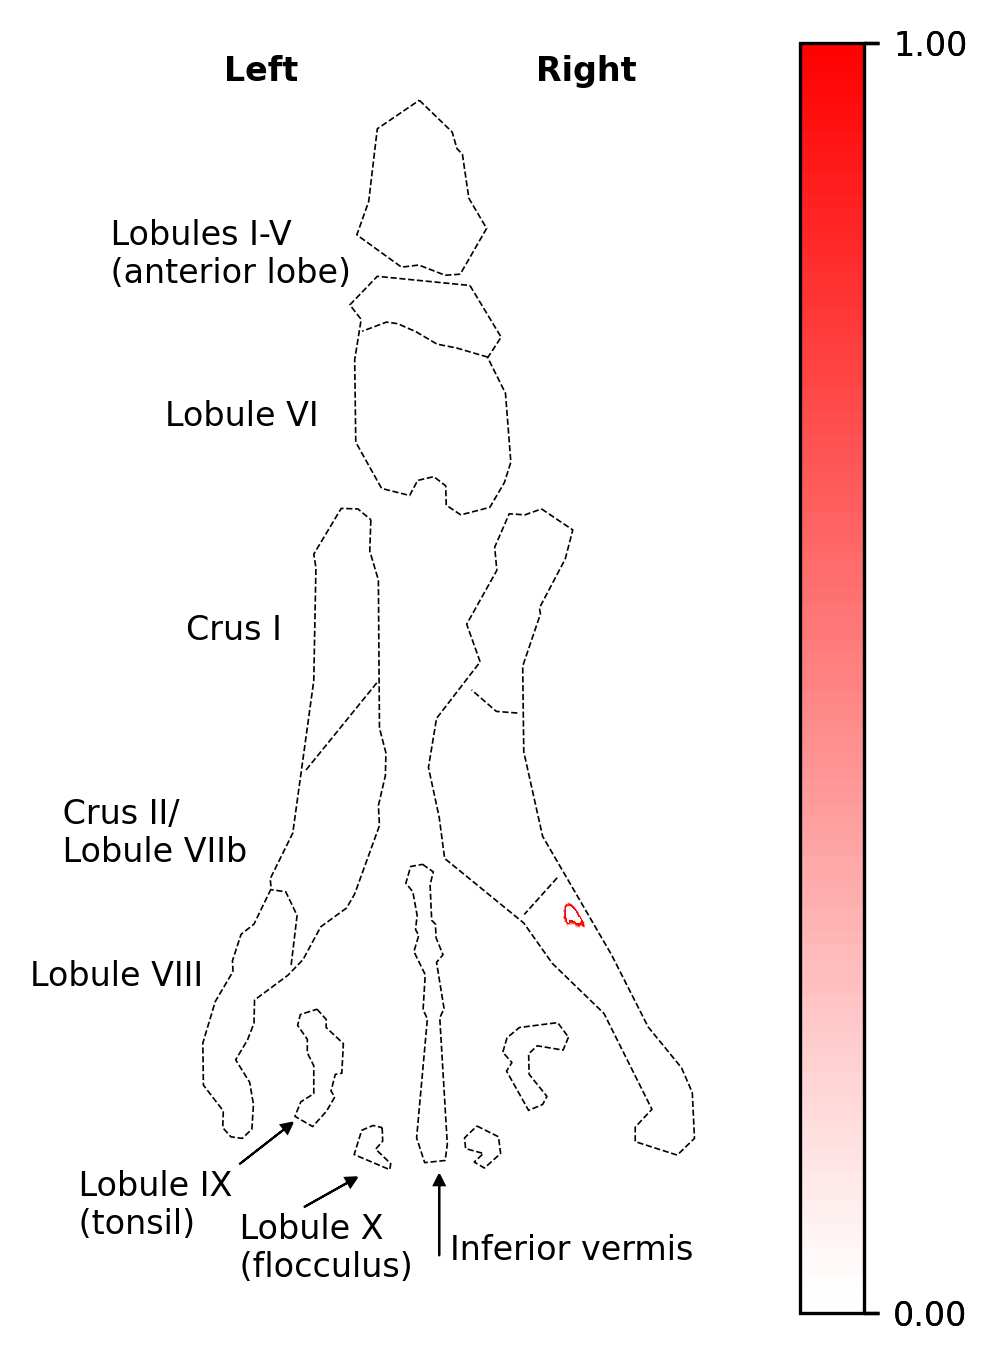

 <Figure size 2100x1650 with 2 Axes>]

In [9]:
# Example forward simulation from patch in right lobule VIIIa
label =  cb_data['parcellation']['fine labels'][714]
active_verts = np.where(np.isin(cb_data['dw_data'][cerebellum_subsampling], label.vertices))[0]
active_verts = np.where(np.isin(fwd['src'][1]['vertno'], active_verts))[0]
act_cerb = np.zeros((fwd['src'][1]['nuse']))
act_cerb[active_verts] = 1

# Plot activated patch (set view to 'all' if not remote connecting)
plot_cerebellum_data(act_cerb, fwd['src'], src_whole, cb_data, cort_data=np.zeros(fwd['src'][0]['nuse']), flatmap_cmap='bwr', mayavi_cmap='OrRd',
                     smoothing_steps=0, view='all', sub_sampling=cerebellum_subsampling, cmap_lims=[0,100])

In [ ]:
# Plot estimated activation (set view to 'all' if not remote connecting)
evo = mne.read_evokeds(evo_fname)[0]
sens = np.zeros(evo.info['nchan'])
all_chs = mne.pick_types(evo.info, meg=True, eeg=True, exclude=[])
sens[all_chs] = np.sum(fwd['sol']['data'][:, fwd['src'][0]['nuse']+active_verts]*10**-7,axis=1)
evo._data[all_chs] = np.repeat(sens[all_chs].reshape((len(all_chs),1)), repeats=evo._data.shape[1], axis=1)
estimate = mne.minimum_norm.apply_inverse(evo, inverse_operator, 1/9, 'sLORETA', verbose='WARNING')
estimate_cerb = np.linalg.norm(estimate.data[fwd['src'][0]['nuse']:estimate.shape[0], :], axis=1)
cort_data = np.linalg.norm(estimate.data[:fwd['src'][0]['nuse'], :], axis=1)

plot_cerebellum_data(estimate_cerb, fwd['src'], src_whole, cb_data, cort_data=cort_data, flatmap_cmap='bwr',
                         mayavi_cmap='OrRd', smoothing_steps=0, view='all', sub_sampling=cerebellum_subsampling,
                         cmap_lims=[25,75])

In [ ]:
# Sensitivity maps - cerebellum only
for ch_type in ['mag', 'grad', 'eeg']:
    ch_inds = mne.channel_indices_by_type(fwd['info'])
    signal_norms = np.linalg.norm(fwd['sol']['data'][ch_inds[ch_type], fwd['src'][0]['nuse']:], axis=0)
    plot_cerebellum_data(signal_norms, fwd['src'], src_whole, cb_data, cort_data=np.zeros(fwd['src'][0]['nuse']), flatmap_cmap='bwr',
                             mayavi_cmap='OrRd', smoothing_steps=0, view='normal', sub_sampling=cerebellum_subsampling,
                             cmap_lims=[25,75])
# Sensitivity maps - with cortex
for ch_type in ['mag', 'grad', 'eeg']:
    ch_inds = mne.channel_indices_by_type(fwd['info'])
    signal_norms = np.linalg.norm(fwd['sol']['data'][ch_inds[ch_type], :], axis=0)
    plot_cerebellum_data(signal_norms[fwd['src'][0]['nuse']:], fwd['src'], src_whole, cb_data, cort_data=signal_norms[:fwd['src'][0]['nuse']], flatmap_cmap='bwr',
                             mayavi_cmap='OrRd', smoothing_steps=0, view='normal', sub_sampling=cerebellum_subsampling,
                             cmap_lims=[25,75])